# 04 · Factorial effects, interactions, marginal means and mixed effects

Demonstrate how Ruddy separates global factorial effects, adjusted means, pairwise contrasts, model diagnostics and hierarchical random effects.

In [9]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd().resolve()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'examples' / 'notebooks'))
from _helpers import *
configure_plots()

from ruddy import analyze_factorial, analyze_marginal_means, analyze_mixed_effects
frame,dataset=load_tabular_demo(); mf,mixed_ds=load_mixed_demo()
fac=analyze_factorial(dataset,response='activity',factors=('group','source'),covariates=('length',),interactions=(('group','source'),),ss_type=3)
emm=analyze_marginal_means(dataset,response='activity',factors=('group','source'),covariates=('length',),interactions=(('group','source'),),terms=('group',('group','source')))
mix=analyze_mixed_effects(mixed_ds,group='batch',response='y',factors=('condition',),covariates=('x',))

## Factorial effect sizes

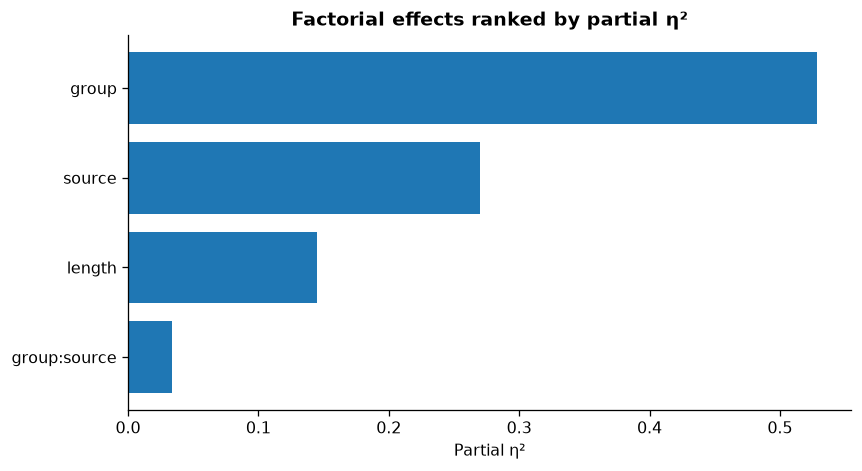

,term,f_value,p_value,partial_eta_squared,omega_squared
0,group,96.807799,6.119864e-29,0.528116,0.379213
1,source,63.981962,1.730860e-13,0.269987,0.124643
2,length,29.347686,2.002010e-07,0.145036,0.056101
3,group:source,2.988968,5.294582e-02,0.033400,0.007872


In [10]:
effects=fac.effects.query('status=="ok"').copy(); bar_metric(effects,label='term',value='partial_eta_squared',title='Factorial effects ranked by partial η²',ylabel='Partial η²'); plt.show(); display(effects[['term','f_value','p_value','partial_eta_squared','omega_squared']])

## Raw interaction view

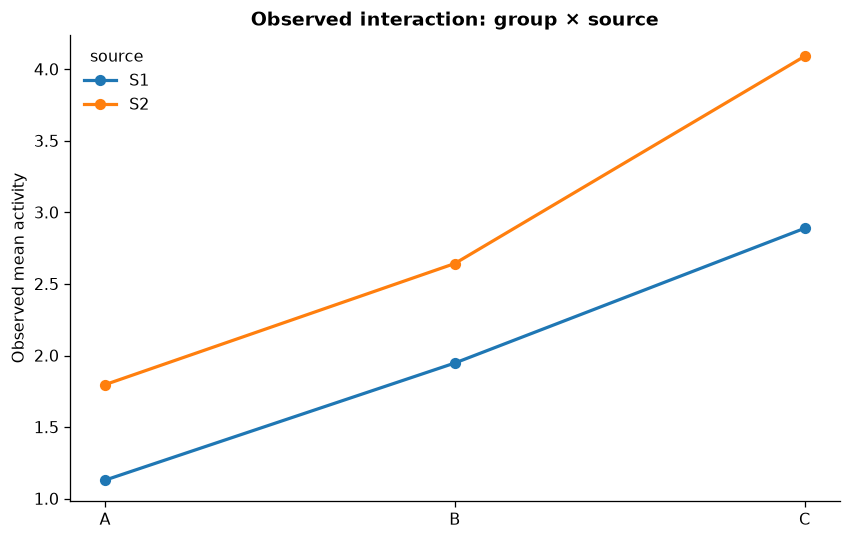

In [11]:
means=frame.replace([np.inf,-np.inf],np.nan).groupby(['group','source'],as_index=False).activity.mean(); fig,ax=plt.subplots(figsize=(7.5,4.8))
for src,sub in means.groupby('source'): ax.plot(sub.group,sub.activity,marker='o',label=src,linewidth=2)
ax.set_ylabel('Observed mean activity'); ax.set_title('Observed interaction: group × source'); ax.legend(title='source'); finish(fig); plt.show()

## Estimated marginal means and adjusted interaction

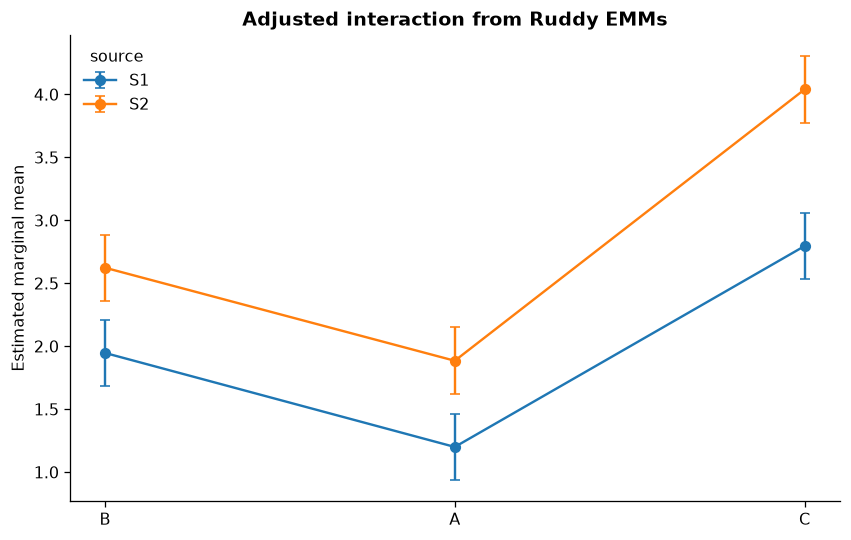

In [12]:
joint=emm.means.query('term=="group:source" and status=="ok"').copy(); joint['levels']=joint.levels_json.map(json.loads); joint['group']=joint.levels.map(lambda x:x['group']); joint['source']=joint.levels.map(lambda x:x['source']); fig,ax=plt.subplots(figsize=(7.5,4.8))
for src,sub in joint.groupby('source'): ax.errorbar(sub.group,sub.estimate,yerr=[sub.estimate-sub.ci_lower,sub.ci_upper-sub.estimate],marker='o',capsize=3,label=src)
ax.set_ylabel('Estimated marginal mean'); ax.set_title('Adjusted interaction from Ruddy EMMs'); ax.legend(title='source'); finish(fig); plt.show()

## Pairwise EMM contrasts

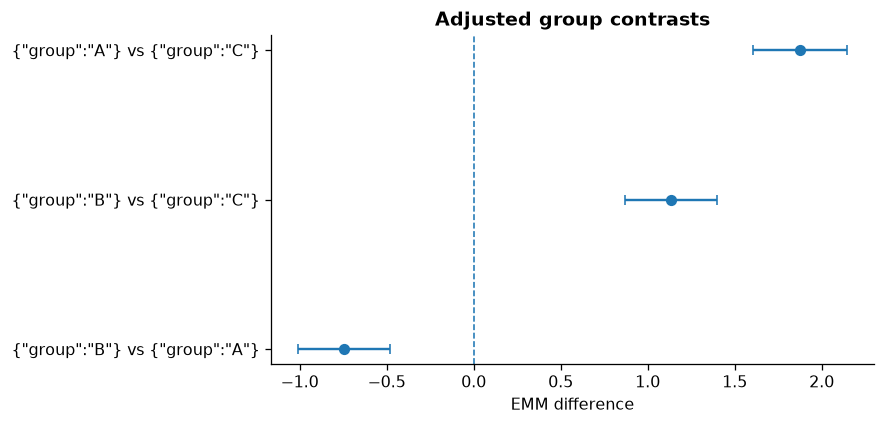

In [13]:
c=emm.contrasts.query('term=="group" and status=="ok"').copy(); c['contrast']=c.levels_a_json+' vs '+c.levels_b_json
errorbar_table(c,label_col='contrast',estimate_col='estimate_difference',low_col='ci_lower',high_col='ci_upper',title='Adjusted group contrasts',xlabel='EMM difference'); plt.show()

## Residual and influence diagnostics

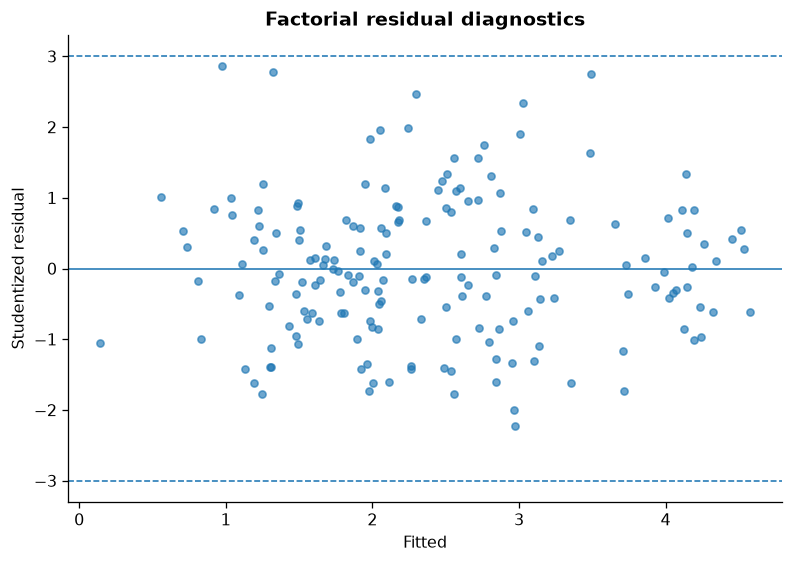

In [14]:
od=fac.observation_diagnostics.query('status=="ok"'); fig,ax=plt.subplots(figsize=(7,5)); ax.scatter(od.fitted_value,od.studentized_residual,s=20,alpha=.65); ax.axhline(0,linewidth=1); ax.axhline(3,linestyle='--',linewidth=1); ax.axhline(-3,linestyle='--',linewidth=1); ax.set_xlabel('Fitted'); ax.set_ylabel('Studentized residual'); ax.set_title('Factorial residual diagnostics'); finish(fig); plt.show()

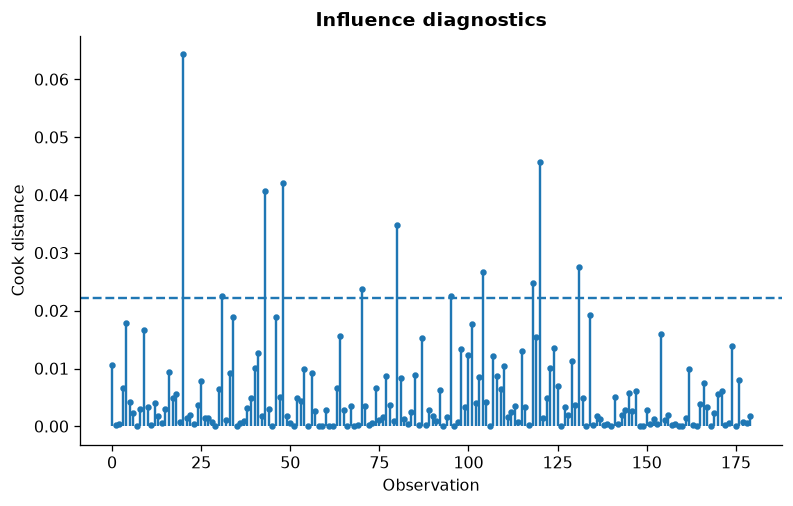

In [15]:
fig,ax=plt.subplots(figsize=(7,4.5)); ax.stem(np.arange(len(od)),od.cooks_distance,markerfmt='.',basefmt=' '); ax.axhline(float(od.cooks_distance_threshold.iloc[0]),linestyle='--'); ax.set_xlabel('Observation'); ax.set_ylabel('Cook distance'); ax.set_title('Influence diagnostics'); finish(fig); plt.show()

## Mixed-effects structure

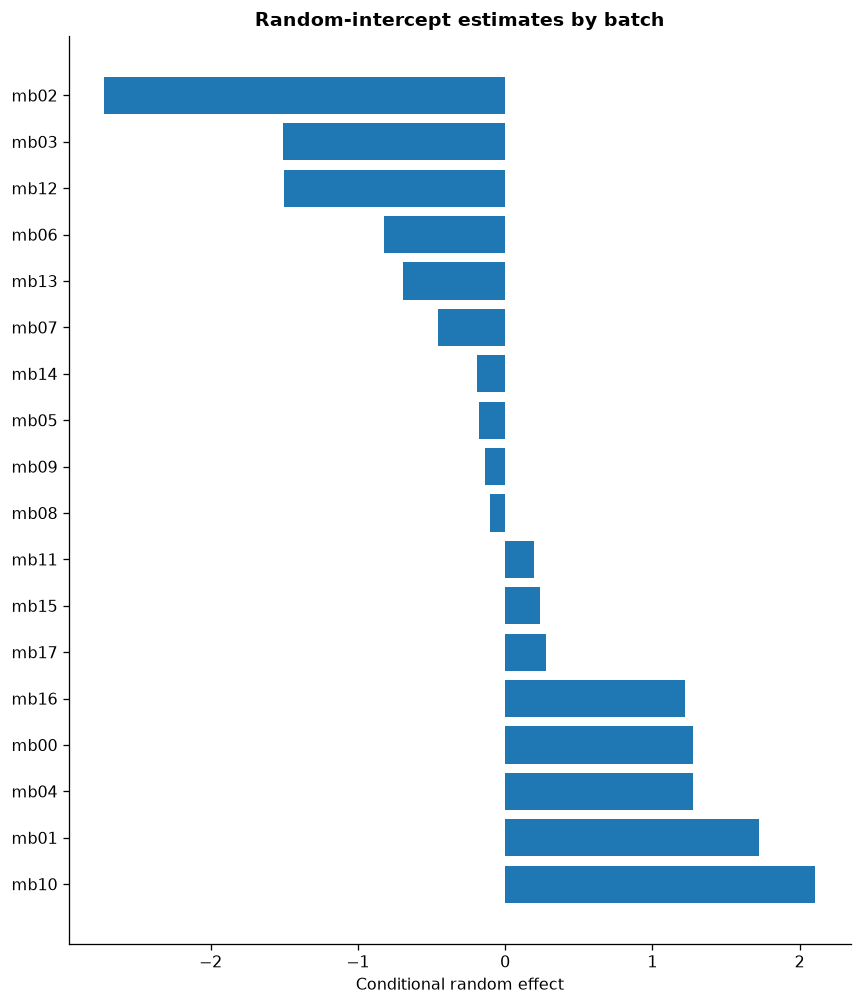

,fixed_formula,random_formula,n_complete_case,n_groups,converged,singular_random_effect_covariance,reml,log_likelihood,aic,bic,residual_variance,random_intercept_variance,icc_random_intercept
0,"Y ~ C(F0, Sum) + X0",1,252,18,True,False,True,-242.939919,None,None,0.287008,1.534774,0.842457


In [16]:
re=mix.random_effects.query('status=="ok"').sort_values('estimate'); bar_metric(re,label='group',value='estimate',title='Random-intercept estimates by batch',ylabel='Conditional random effect'); plt.show(); display(pd.DataFrame([mix.model_summary]))